# 2. Where the tokens go

The headline finding of this dataset: on the input side, 98 percent of all tokens
are cache reads. Everything else about cost in an agent session follows from
that.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DATA = Path.cwd().parent / "data"
sessions = pd.read_parquet(DATA / "sessions.parquet")
events = pd.read_parquet(DATA / "events.parquet")
print(f"{len(sessions):,} sessions, {len(events):,} events")

1,213 sessions, 181,406 events


In [2]:
from agent_telemetry.analysis import economics

mix = economics.token_mix(sessions).to_frame("tokens")
mix["share"] = (mix["tokens"] / mix["tokens"].sum()).round(4)
mix

,tokens,share
input_tokens,170227671,0.0095
output_tokens,46618902,0.0026
cache_creation_tokens,144665026,0.0081
cache_read_tokens,17479287945,0.9797


Output tokens are a rounding error. The input side dominates by two orders of
magnitude, because an agent re-sends its entire context on every turn, and the
context grows with every tool result.

In [3]:
print(f"cache hit rate across all sessions: {economics.cache_hit_rate(sessions):.3f}")

cache hit rate across all sessions: 0.982


## What the cache is worth

The comparison below is hypothetical: it prices the same token counts with and
without cache rates. It is not a bill. Subscription sessions are not billed per
token at all, and the rates used are the published defaults for one model.

In [4]:
economics.estimate_cost(sessions).to_frame("usd")

,usd
with_cache,6996.2500
without_cache,54081.8300
saved,47085.5800
saved_share,0.8706


## Cache efficiency against session length

A cache entry has to be written before it can be read, so the first turns of any
session pay full price. The question is how quickly that cost is amortized.

In [5]:
economics.cache_efficiency_by_length(sessions)

,length_bucket,sessions,median_events,cache_read,cache_write,fresh_input,output,cache_hit_rate
0,"(2.0, 11.0]",224,7.0,56537297,312532,3932180,1053878,0.9302
1,"(11.0, 18.0]",183,13.0,103792407,1030112,6653890,1950330,0.9311
2,"(18.0, 33.0]",201,25.0,245600878,1674721,10986783,2292403,0.9510
3,"(33.0, 81.0]",204,51.0,662323543,5775050,27682468,2419666,0.9519
4,"(81.0, 162.0]",198,113.5,1542850241,5280878,63335032,3224333,0.9574
5,"(162.0, 9663.0]",203,241.0,14868183579,130591733,57637318,35678292,0.9875


Even the shortest quantile, sessions with a median of 7 events, already reaches
93 percent. By 241 events it is 99 percent. The cache is not a long-session
optimization; it pays for itself almost immediately.

The practical consequence runs against intuition: restarting a session to keep
the context small throws away the cache and can cost more than continuing a long
one.

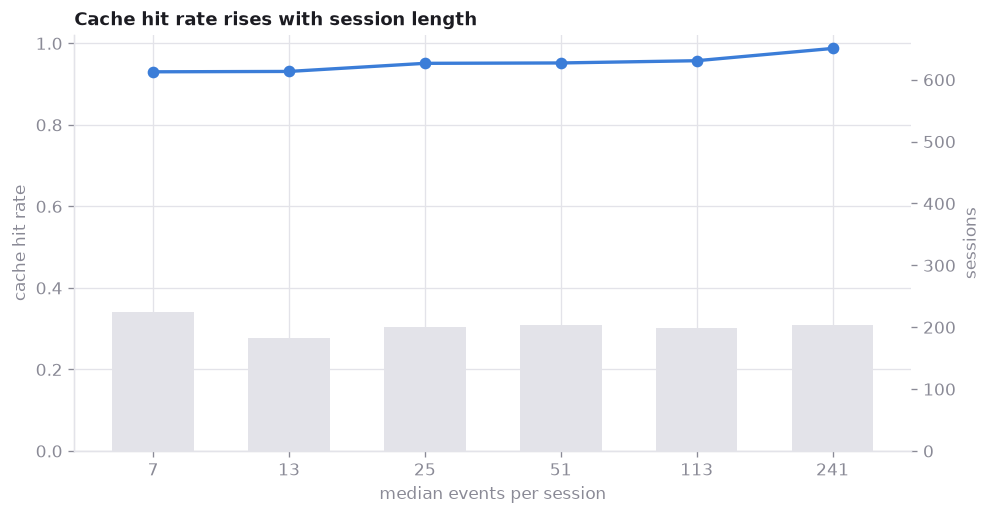

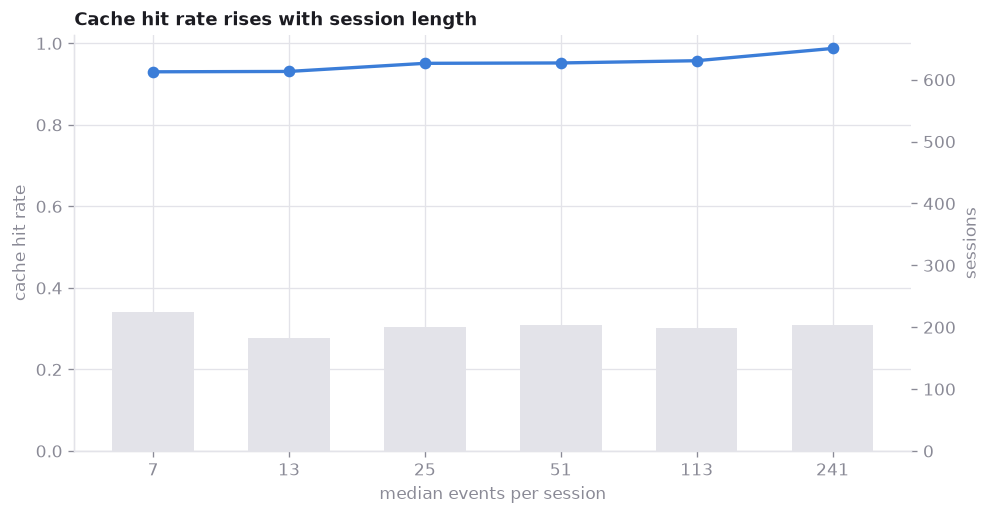

In [6]:
from agent_telemetry import viz

fig = viz.cache_curve(
    economics.cache_efficiency_by_length(sessions),
    "Cache hit rate rises with session length",
)
fig

## Per model

In [7]:
economics.tokens_by_model(sessions).head(10)

,primary_model,sessions,median_events,input_tokens,output_tokens,cache_creation_tokens,cache_read_tokens,cache_hit_rate,output_per_session
0,deepseek-v4-flash,912,31.0,139543379,12848052,1006961,4653769538,0.9707,14088.0
1,claude-sonnet-5,102,113.0,3083231,21268197,90059808,9428416218,0.9902,208512.0
2,,54,8.5,0,0,0,0,NaN,0.0
3,deepseek-v4-pro,38,64.0,15747045,1869939,2577875,1019818332,0.9823,49209.0
4,claude-opus-4-8,28,99.5,1113464,7237830,32651924,1699814678,0.9805,258494.0
5,other,15,34.0,3998531,612503,5882148,211175306,0.9553,40834.0
6,<synthetic>,13,11.0,0,0,0,0,NaN,0.0
7,claude-opus-5,11,197.0,3846,1517447,8242543,277237393,0.9711,137950.0
8,claude-haiku-4-5-20251001,9,4.0,252,16996,238530,552686,0.6983,1888.0
9,qwen/qwen3.5-4b,7,32.0,3872079,31192,0,3138560,0.4477,4456.0


The models differ in cache hit rate more than the aggregate suggests, but they
were also used for different work, so this table describes usage rather than
efficiency.